In [1]:
# Setup path and load utils
import sys, os
sys.path.append(os.path.abspath("../src"))
import numpy as np
print("Current working directory:", os.getcwd())
import sys
for p in sys.path:
    print(p)

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

Current working directory: /home/isesdr/Downloads/ble-RFFingerprinting/notebooks
/usr/lib/python311.zip
/usr/lib/python3.11
/usr/lib/python3.11/lib-dynload

/home/isesdr/Downloads/ble-RFFingerprinting/ble-rff-env/lib/python3.11/site-packages
/home/isesdr/Downloads/ble-RFFingerprinting/src


In [2]:
location = '../disk/2026-05-22_1000ms'

In [3]:
# Extract the features from the labelled bursts

from feature import IQFeatureExtractor
from utils import list_npys_by_timestamp, load_iq_burst
from tqdm import tqdm

# Feature extraction
extractor = IQFeatureExtractor()
records = []

files = list_npys_by_timestamp(f"{location}/packets")

for filename, timestamp, address in tqdm(files, total=len(files), desc='Extracting features', unit='packet'):
    samples = load_iq_burst(f"{location}/packets/{filename}")
    features = extractor.compute_features(samples)
    features['timestamp'] = timestamp
    features['address'] = address
    records.append(features)

df_features = pd.DataFrame(records)
df_features.to_csv(f"{location}/features.csv", index=False)
print(df_features.columns.tolist())  # <- Confirm all fields

Extracting features: 100%|██████████| 1651/1651 [00:19<00:00, 82.68packet/s]


['iq_imbalance', 'iq_gain_imbalance_db', 'iq_phase_imbalance_rad', 'rms_power', 'spectral_entropy', 'cfo_estimate_hz', 'iq_corr', 'phase_noise', 'time_entropy', 'rise_index', 'i_skew', 'q_skew', 'i_kurtosis', 'q_kurtosis', 'fft_peak_0', 'fft_peak_1', 'fft_peak_2', 'fft_peak_3', 'fft_peak_4', 'timestamp', 'address']


address
E7:15:25:E4:1C:74    171
C8:03:74:BD:EE:2D    168
CD:C6:53:1F:73:E0    167
D0:22:2B:0F:58:F6    167
D2:C1:89:A4:11:13    165
CA:21:C7:1B:ED:FE    164
D9:48:77:9E:AD:39    164
C8:38:D4:89:79:BF    162
EC:8B:1B:7A:D5:C5    160
FB:42:CF:CF:61:22    160
30:B1:C8:71:CA:D5      1
B6:17:8F:22:E5:07      1
D5:30:C0:F8:38:15      1
Name: count, dtype: int64


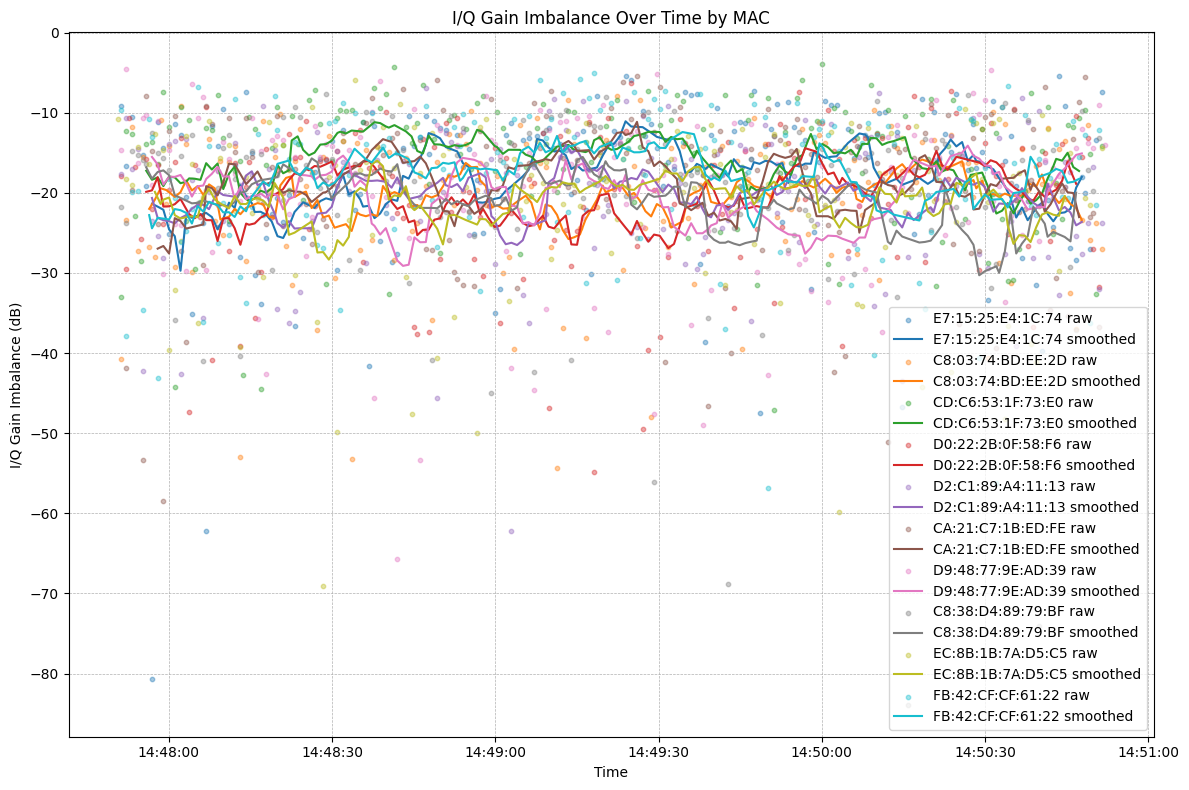

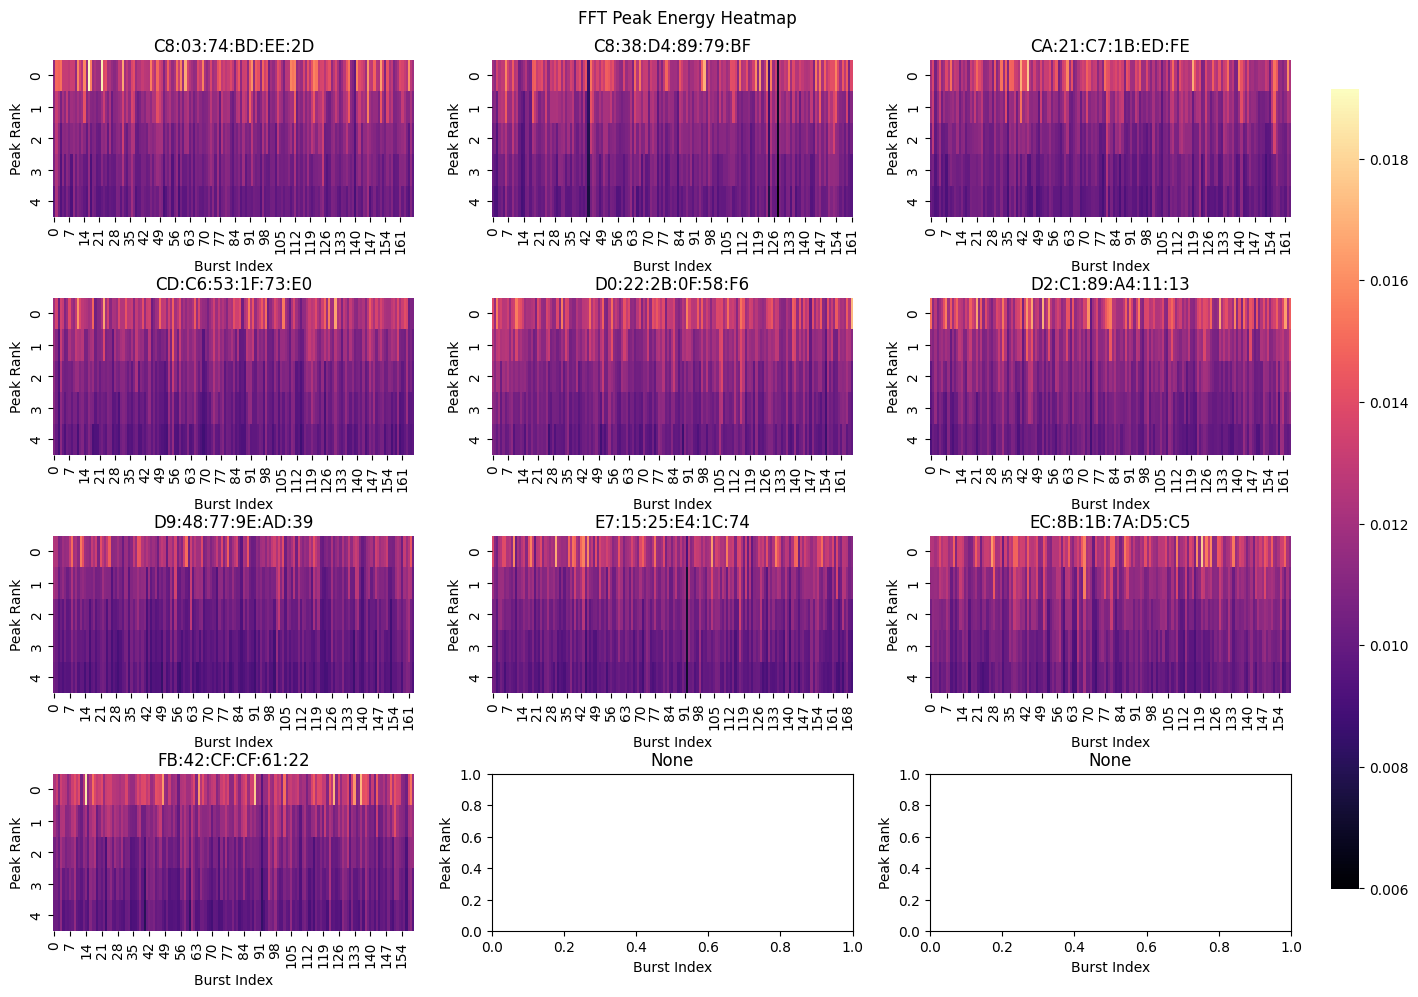

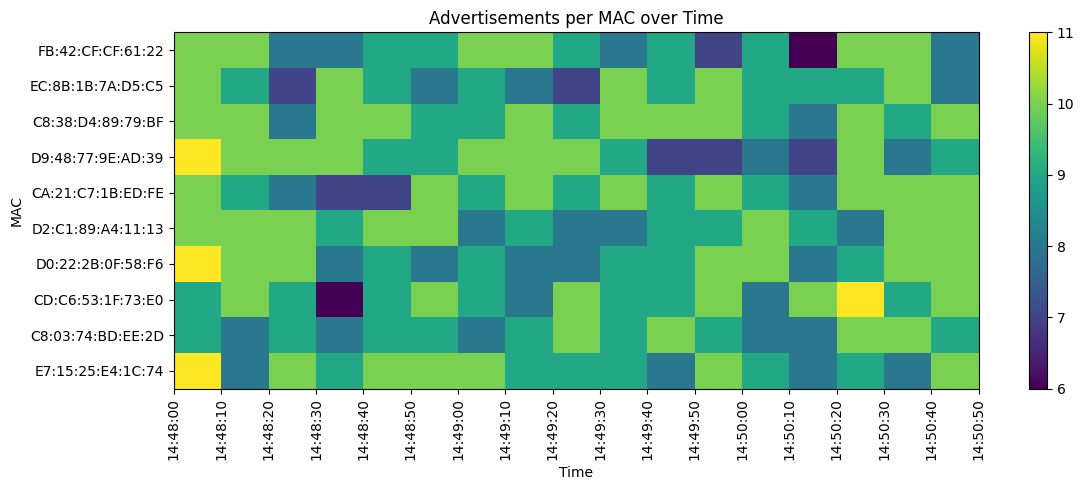

In [4]:
# Print number of adverts per address and plot gain imbalance, CFO drift, FFT peaks and number of adverts over time.

# --- Remove Devices With Few Advertisements
min_adverts = 10 # The minimum number of advertisements for a device to be included

# --- Load Features From Disk
df_features = pd.read_csv(f"{location}/features.csv")
df_features['timestamp'] = pd.to_datetime(df_features['timestamp'])

# --- Remove Devices With Few Adverts
hist_mac = df_features['address'].value_counts()
print(hist_mac)
top_macs = hist_mac[hist_mac > min_adverts].index
df_features = df_features[df_features['address'].isin(top_macs)]

# --- Plot Gain Imbalance
plt.figure(figsize=(12, 8))
for mac in top_macs:  # Assume you already have 'top_macs'
    subset = df_features[df_features['address'] == mac]
    subset = subset.sort_values('timestamp')
    subset['iq_gain_imbalance_db'] = 20 * np.log10(np.abs(subset['iq_gain_imbalance_db']) + 1e-10)
    
    # Optional smoothing
    subset['smoothed'] = subset['iq_gain_imbalance_db'].rolling(window=10, center=True).mean()
    
    plt.scatter(subset['timestamp'], subset['iq_gain_imbalance_db'], s=10, alpha=0.4, label=f"{mac} raw")
    plt.plot(subset['timestamp'], subset['smoothed'], label=f"{mac} smoothed")

plt.ylabel("I/Q Gain Imbalance (dB)")
plt.xlabel("Time")
plt.title("I/Q Gain Imbalance Over Time by MAC")
plt.legend()
plt.grid(True, linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

# --- Plot FFT Peaks
fig, axs = plt.subplots(nrows=int(len(top_macs)/3)+1, ncols=min(len(top_macs),3), figsize=(14,10))
groups = dict(tuple(df_features.groupby('address')))
fft_peaks_cols = [col for col in df_features.columns if col.startswith('fft_peak_')]
vmin = df_features[fft_peaks_cols].min(axis=None)
vmax = df_features[fft_peaks_cols].max(axis=None)

# Add labels and titles ahead of time to allow for calling fig.tight_layout before fig.add_axes as calling
# them the other way around would cause a warning about cbar_ax being unsupported in the tight layout.
for ax in axs.flatten():
    ax.set_xlabel("Burst Index")
    ax.set_ylabel("Peak Rank")
    ax.set_title("None")

fig.suptitle("FFT Peak Energy Heatmap")
fig.tight_layout(rect=[0, 0, .95, 1])
cbar_ax = fig.add_axes([.96, .1, .02, .8])

for i, (ax, item) in enumerate(zip(axs.flatten(), groups.items())):
    fft_peaks_cols = [col for col in item[1].columns if col.startswith('fft_peak_')]
    fft_matrix = item[1][fft_peaks_cols].values
    sns.heatmap(fft_matrix.T, ax=ax, vmin=vmin, vmax=vmax, cbar=(i==0), cmap='magma', cbar_ax=cbar_ax)
    ax.set_xlabel("Burst Index")
    ax.set_ylabel("Peak Rank")
    ax.set_title(item[0])

plt.show()

# --- Plot Number of Adverts over Time
fig, ax = plt.subplots(figsize=(12, 5))

start_time = df_features['timestamp'].min().ceil('10s')
end_time = df_features['timestamp'].max().floor('10s')
df_features['address_id'] = pd.factorize(df_features['address'])[0]
_, xedges, yedges, img = plt.hist2d(
    df_features['timestamp'], df_features['address_id'],
    bins = [np.array(pd.date_range(start_time, end_time, freq='10s')), np.array(range(0, len(top_macs)+1))-0.5]
)
plt.colorbar(img, ax=ax)

plt.xticks(xedges, labels=pd.date_range(start_time, end_time, freq='10s').strftime('%H:%M:%S'), rotation=90)
plt.yticks(range(0,len(top_macs)), labels=top_macs)

plt.title("Advertisements per MAC over Time")
plt.xlabel("Time")
plt.ylabel("MAC")
plt.tight_layout()
plt.show()

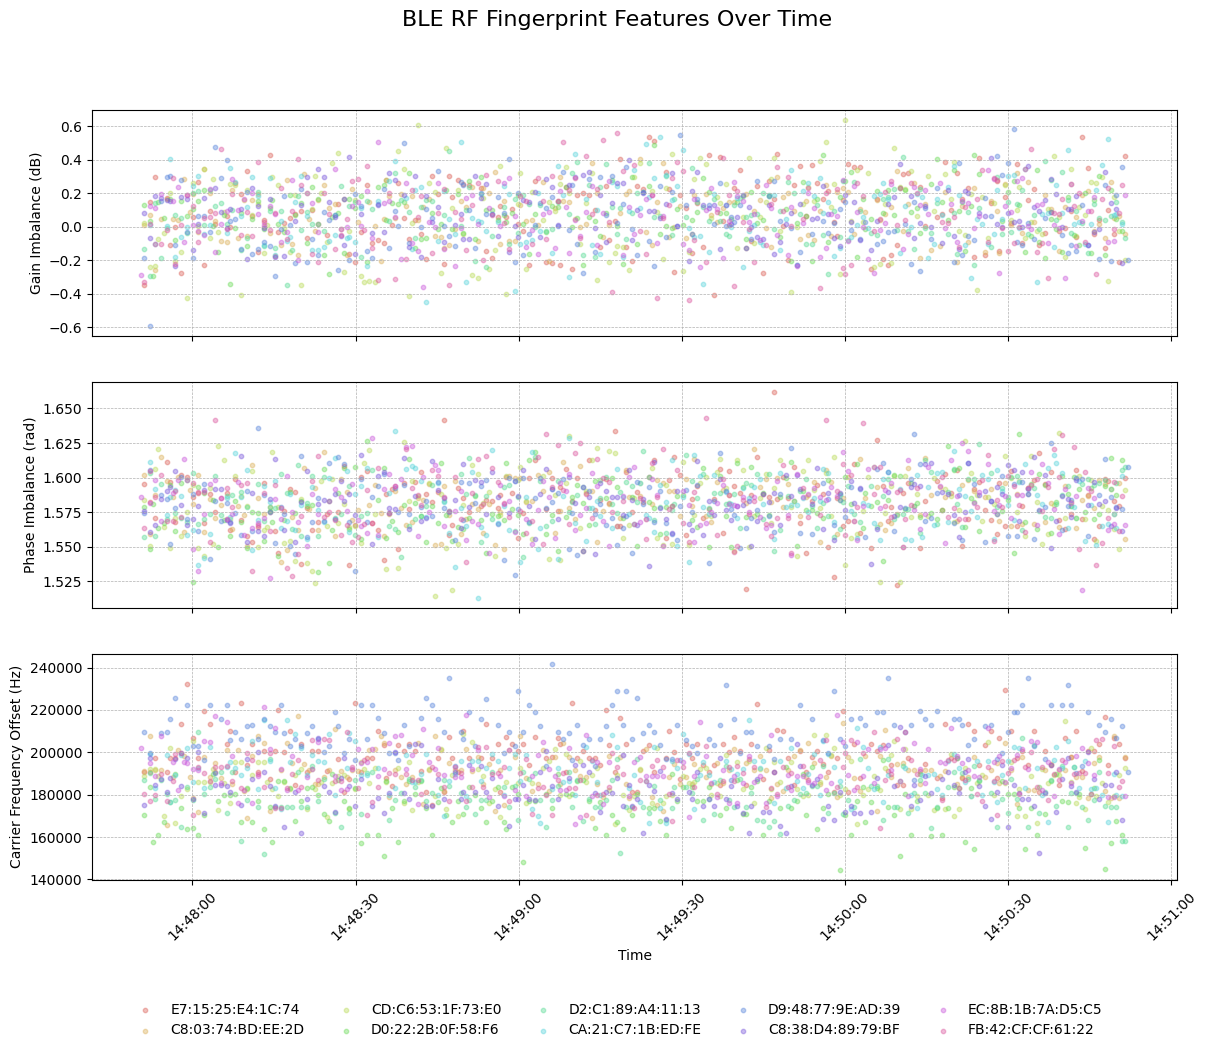

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Metrics and their new axis labels
plot_fields = {
    "iq_gain_imbalance_db": "Gain Imbalance (dB)",
    "iq_phase_imbalance_rad": "Phase Imbalance (rad)",
    "cfo_estimate_hz": "Carrier Frequency Offset (Hz)"
}

palette = sns.color_palette("hls", len(top_macs))

# Plotting
for plot_nr, (ax, (field, label)) in enumerate(zip(axs, plot_fields.items())):
    for i, mac in enumerate(top_macs):
        subset = df_features[df_features['address'] == mac].copy()
        subset = subset.sort_values("timestamp")

        # Optional: outlier filtering for visual clarity
        if "imbalance" in field:
            subset = subset[np.abs(subset[field]) < 100]

        ax.scatter(
            subset['timestamp'], subset[field],
            s=10, alpha=0.4, label=mac if not plot_nr else '', color=palette[i]
        )

    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", linewidth=0.5)
    ax.set_yscale("linear")  # CFO is linear in Hz; imbalance metrics also okay on linear

# Shared x-axis and legend
axs[-1].set_xlabel("Time")
fig.suptitle("BLE RF Fingerprint Features Over Time", fontsize=16)
plt.xticks(rotation=45)
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0), ncol=len(top_macs)/2, frameon=False)
plt.show()

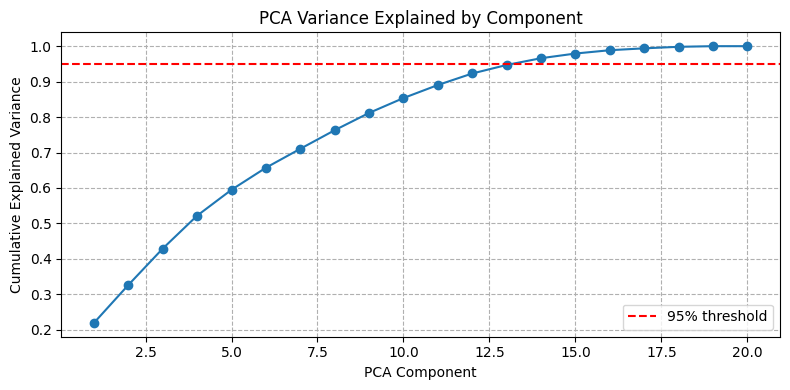

? Components needed for >=95% variance: 14
? Top contributing features to PC1:


,PC1,PC2,PC3
fft_peak_3,0.397555,0.188653,0.053824
fft_peak_2,0.395503,0.200529,0.076066
fft_peak_4,0.377720,0.157465,0.042444
fft_peak_1,0.363830,0.188407,0.087968
spectral_entropy,0.357035,0.223003,0.071960
fft_peak_0,0.271012,0.126086,0.071906
phase_noise,0.222028,0.077911,0.086031
q_kurtosis,0.209060,0.455650,0.159129
i_kurtosis,0.204493,0.444895,0.117519
cfo_estimate_hz,0.165824,0.101293,0.003638


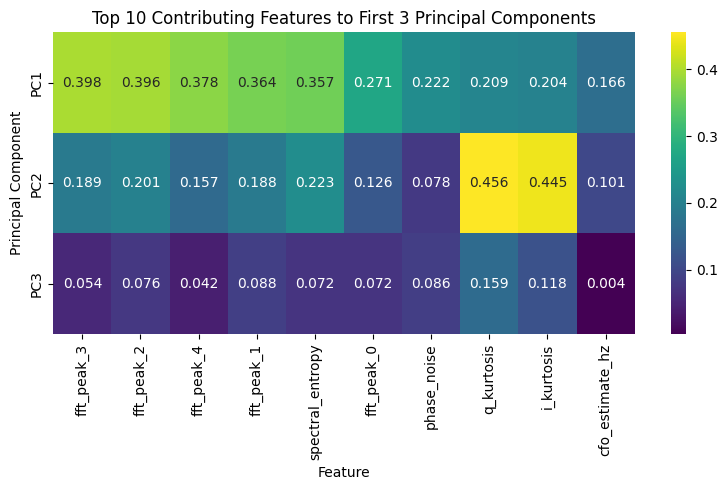

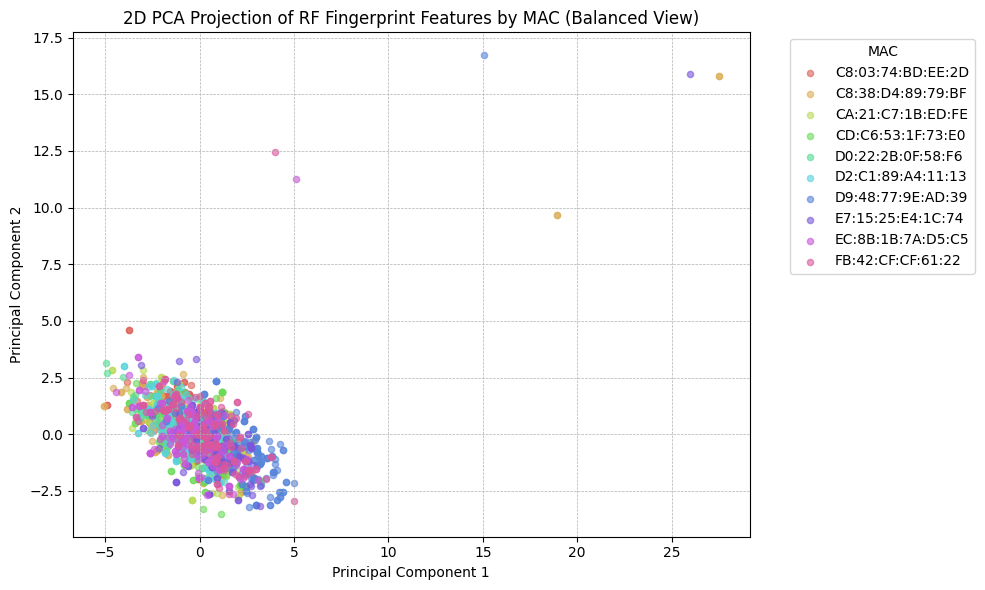

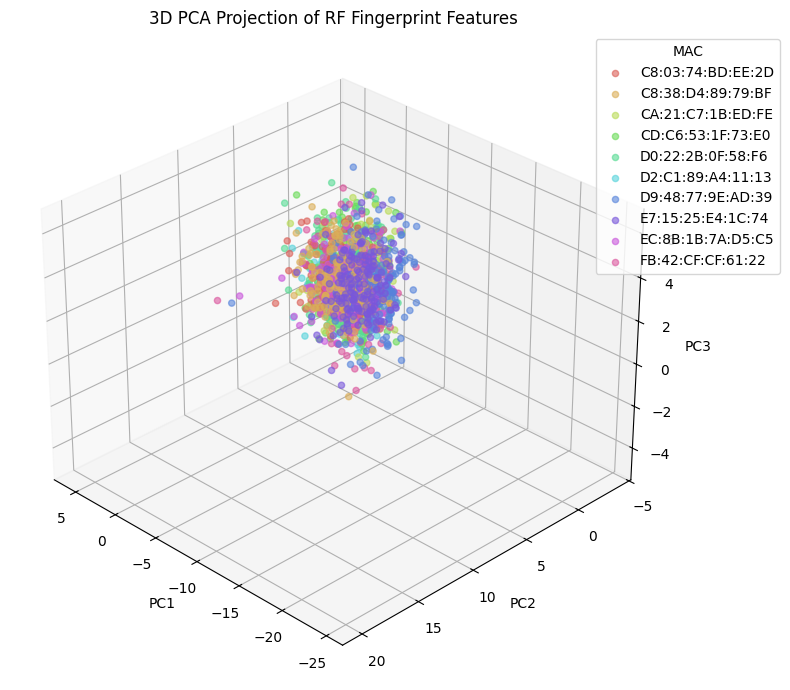

In [6]:
# --- Setup
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D

# --- Select numeric features
exclude_cols = ['timestamp', 'burst_timestamp', 'matched_macs', 'matched_rssi']
feature_cols = [
    col for col in df_features.columns
    if col not in exclude_cols and not isinstance(df_features[col].iloc[0], (str, dict, list))
]

# --- Prepare and scale data
X = df_features[feature_cols]
macs = df_features['address']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Full PCA
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)
explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# --- Plot cumulative explained variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.95, color='r', linestyle='--', label='95% threshold')
plt.xlabel("PCA Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Variance Explained by Component")
plt.grid(True, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

# --- Identify how many PCs needed
n_components = np.argmax(cum_var >= 0.95) + 1
print(f"? Components needed for >=95% variance: {n_components}")

# --- Top 3 contributing features
loading_matrix = pd.DataFrame(
    pca_full.components_[:3],
    columns=feature_cols,
    index=["PC1", "PC2", "PC3"]
)
top_features = loading_matrix.abs().T.sort_values("PC1", ascending=False).head(10)

print("? Top contributing features to PC1:")
display(top_features)

# --- Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(top_features.T, annot=True, fmt=".3f", cmap="viridis", cbar=True)
plt.title("Top 10 Contributing Features to First 3 Principal Components")
plt.xlabel("Feature")
plt.ylabel("Principal Component")
plt.tight_layout()
plt.show()

# --- 2D PCA visualization with optional balancing
from sklearn.utils import resample
df_vis = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)
df_vis["mac"] = macs

# Take max 500 samples per MAC
df_samples = pd.concat([
    resample(g, n_samples=min(500, len(g)), random_state=42)
    for _, g in df_vis.groupby("mac")
])

pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(df_samples[feature_cols])
mac_labels_vis = df_samples["mac"].values

# --- 2D scatter plot
plt.figure(figsize=(10, 6))
unique_macs = sorted(pd.Series(mac_labels_vis).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (mac_labels_vis == mac)
    plt.scatter(X_vis[idx, 0], X_vis[idx, 1], s=20, alpha=0.6,
                label=mac, color=palette[i % len(palette)])

plt.title("2D PCA Projection of RF Fingerprint Features by MAC (Balanced View)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend(title="MAC", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 3D PCA projection
pca_vis = PCA(n_components=3)
X_vis = pca_vis.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
unique_macs = sorted(pd.Series(macs).unique())
palette = sns.color_palette("hls", len(unique_macs))

for i, mac in enumerate(unique_macs):
    idx = (macs == mac)
    ax.scatter(X_vis[idx, 0], X_vis[idx, 1], X_vis[idx, 2],
               label=mac, alpha=0.6, s=20, color=palette[i % len(palette)])

ax.set_title("3D PCA Projection of RF Fingerprint Features")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.view_init(elev=30, azim=135)
ax.legend(title="MAC", bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()
